In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.523800000011921 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.13                          pyhcf101f3_0                  conda-forge                   
+ joblib                     

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('NYPD_Arrest_Data_(Year_to_Date)_20260506.csv')

In [4]:
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,01/06/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,01/03/2026,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,01/08/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,01/07/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,01/10/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)


In [8]:
#identifying if there are any values in this column not listed in the description
df['LAW_CAT_CD'].unique()

<StringArray>
['F', 'M', 'V', '9', nan, 'I', '(null)']
Length: 7, dtype: str

In [9]:
#counting how many records are not listed in the description and if it might be a lot
df['LAW_CAT_CD'].value_counts()

LAW_CAT_CD
M         40761
F         26889
V          1123
9           210
I            53
(null)        2
Name: count, dtype: int64

In [10]:
#taking a look if how many non-NYPD jurisdiction records there are
df['JURISDICTION_CODE'].value_counts()

JURISDICTION_CODE
0     57588
1      7520
2      2404
17      642
3       502
72      143
97      122
11      110
73      100
51       56
7        31
71       29
14       27
52       11
4         7
87        4
85        2
12        2
69        2
13        1
88        1
74        1
Name: count, dtype: int64

In [11]:
#M - Manhattan, B - Bronx, K - Brooklyn, Q - Queens, S - Staten Island
#to create a new column to show specific boroughs

borough_map = {
    'K': 'Brooklyn',
    'B': 'Bronx',
    'M': 'Manhattan',
    'S': 'Staten Island',
    'Q': 'Queens'
}

# Extract the letter and define using mapping dictionary into new column
df['Arrest Borough'] = df['ARREST_BORO'].str.extract(r'([KBMSQ])')[0].map(borough_map)

In [12]:
#F - Felony, M - Misdemeanor, V - Violation
#to create a new column to show specific level of offense

offense_map = {
    'F': 'Felony',
    'M': 'Misdemeanor',
    'V': 'Violation'
}

# Extract the letter and define using mapping dictionary into new column
df['Level of Offense'] = df['LAW_CAT_CD'].str.extract(r'([FMV])')[0].map(offense_map)

In [13]:
#0 - Patrol, 1 - Transit, 2 - Housing
#to create a new column to show Jurisdiction

jurisdiction_map = {
    0: 'Patrol',
    1: 'Transit',
    2: 'Housing'
}

# Create new column
df['Jurisdiction'] = df['JURISDICTION_CODE'].map(jurisdiction_map)

In [14]:
#cleaning Jurisdiction column - removing all rows where the jurisdiction code is less than or equal to 2
#codes higher than 2 are outside of NYPD jurisdiction
df = df[df['JURISDICTION_CODE'] <= 2]

In [15]:
#cleaning Law Code column to remove all rows where the level of offense 
#cannot be defined based on the column description provided
df = df[df['LAW_CAT_CD'].isin(['F', 'M', 'V'])]

In [16]:
#defining columns to drop and dropping from df
drop_cols = ['PD_CD', 'KY_CD','LAW_CODE', 'ARREST_BORO', 'LAW_CAT_CD', 'JURISDICTION_CODE']
df.drop(drop_cols, inplace = True, axis=1)

In [17]:
#cleaning to remove all null/unknown records in Age Group, Sex, and Race columns
df = df[
    (df['AGE_GROUP'] != '(null)') &
    (df['PERP_SEX'] != '(null)') &
    (df['PERP_RACE'] != '(null)') &
    (df['PERP_RACE'] != 'UNKNOWN')
]

In [18]:
df.head()

,ARREST_KEY,ARREST_DATE,PD_DESC,OFNS_DESC,ARREST_PRECINCT,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location,Arrest Borough,Level of Offense,Jurisdiction
0,318451126,01/06/2026,STRANGULATION 1ST,FELONY ASSAULT,110,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989),Queens,Felony,Patrol
1,318308486,01/03/2026,"TRESPASS 3, CRIMINAL",CRIMINAL TRESPASS,77,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784),Brooklyn,Misdemeanor,Transit
2,318550123,01/08/2026,STRANGULATION 1ST,FELONY ASSAULT,48,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152),Bronx,Felony,Patrol
4,318684449,01/10/2026,"ROBBERY,OPEN AREA UNCLASSIFIED",ROBBERY,45,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401),Bronx,Felony,Patrol
5,318772893,01/12/2026,"ARSON 2,3,4",ARSON,28,25-44,M,BLACK,998296,234474,40.810250,-73.949261,POINT (-73.949261 40.81025),Manhattan,Felony,Patrol


In [19]:
# Calculate percentage of total arrests that occurred in each borough out of all the arrests
borough_percent = (df['Arrest Borough'].value_counts(normalize=True)*100)

print(borough_percent)

Arrest Borough
Brooklyn         33.056340
Queens           22.937458
Manhattan        20.665182
Bronx            19.152320
Staten Island     4.188700
Name: proportion, dtype: float64


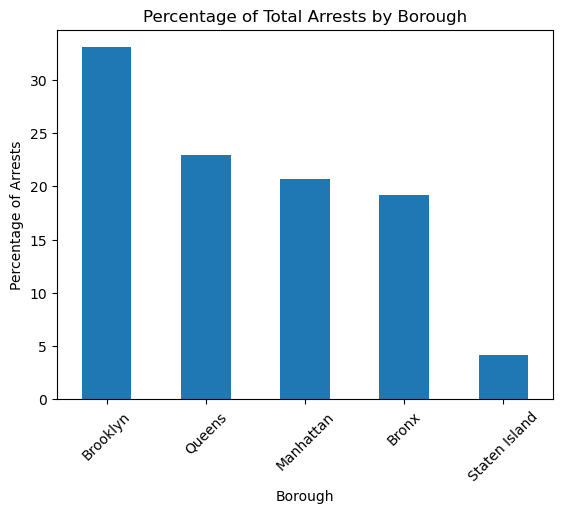

In [20]:
# Create bar chart
borough_percent.plot(kind='bar')

plt.title('Percentage of Total Arrests by Borough')
plt.xlabel('Borough')
plt.ylabel('Percentage of Arrests')
plt.xticks(rotation=45)
plt.show()


#Out of all of the arrests that occurred in New York City, 33% occurred in Brooklyn.

In [21]:
#grouping arrests by borough and then the level of offense
borough_offense = df.groupby(['Arrest Borough', 'Level of Offense']).size().unstack()

#calculating what percent of the arrests in each borough are felony, misdemeanor, or violation out of all the arrests
borough_offense_percent = (borough_offense / len(df)) * 100

print(borough_offense_percent)

Level of Offense     Felony  Misdemeanor  Violation
Arrest Borough                                     
Bronx              8.850543    10.267981   0.033796
Brooklyn          14.486502    17.637470   0.932368
Manhattan          9.393265    11.230170   0.041748
Queens             9.409169    13.134667   0.393623
Staten Island      1.767325     2.419387   0.001988


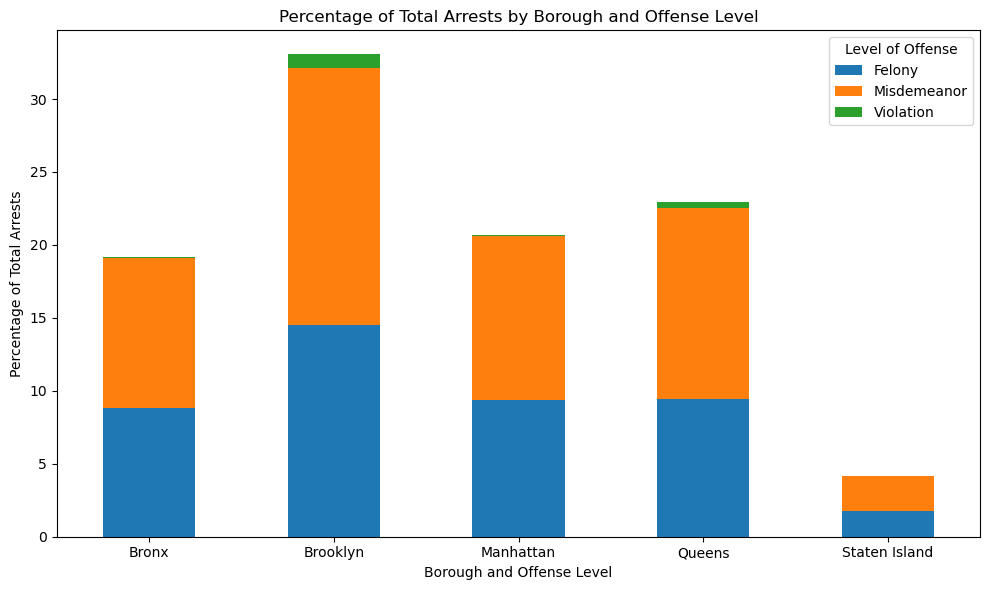

In [22]:
#visualizing
borough_offense_percent.plot(kind='bar', stacked=True, figsize=(10,6))

# Add title
plt.title('Percentage of Total Arrests by Borough and Offense Level')

# Label axes
plt.xlabel('Borough and Offense Level')
plt.ylabel('Percentage of Total Arrests')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Of the 33% arrests that occurred in Brooklyn, 14% were Felonies, 17.6% were Misdemeanors, and .93% were Violations

In [23]:
#Viewing only Brooklyn arrests
brooklyn_df = df[df['Arrest Borough'] == 'Brooklyn']

#viewing what count of arrests in Brooklyn happened were either male or female arrests
brooklyn_sex_ct = brooklyn_df['PERP_SEX'].value_counts()
print(brooklyn_sex_ct)

#viewing what percentage of arrests in Brooklyn were either male or female arrests
brooklyn_sex_pct = brooklyn_df['PERP_SEX'].value_counts(normalize=True)*100
print(brooklyn_sex_pct)


PERP_SEX
M    13612
F     3016
Name: count, dtype: int64
PERP_SEX
M    81.86192
F    18.13808
Name: proportion, dtype: float64


In [24]:
#grouping the sex by level of offense
brooklyn_sex_offense = brooklyn_df.groupby(['PERP_SEX', 'Level of Offense']).size()

# Convert counts into percentages within each sex
brooklyn_sex_offense_pct = (brooklyn_sex_offense.groupby(level=0).apply(lambda x: x / x.sum() * 100))

# Show results
brooklyn_sex_offense_pct

#81.86% of arrests that occurred in Brooklyn were of males. 
#52% of those arrests were categorized as Misdemeanors and 44% were categorized as Felonies. 

PERP_SEX  PERP_SEX  Level of Offense
F         F         Felony              42.871353
                    Misdemeanor         55.868700
                    Violation            1.259947
M         M         Felony              44.034675
                    Misdemeanor         52.799001
                    Violation            3.166324
dtype: float64

In [25]:
#looking for the top offenses after grouping for sex and type of level of offense
brooklyn_offenses = brooklyn_df.groupby(['PERP_SEX', 'Level of Offense', 'OFNS_DESC']).size().reset_index(name='Count')

#calculate percentage of offense that occurs out of all of the arrests for each sex group in Brooklyn
brooklyn_offenses['Percentage'] = (brooklyn_offenses['Count']/brooklyn_offenses.groupby('PERP_SEX')['Count'].transform('sum')) * 100

# Sort by sex and level of offense and the offense
brooklyn_offenses = brooklyn_offenses.sort_values(['PERP_SEX', 'Level of Offense', 'Count'],ascending=[True, True, False])

# Get TOP 3 offenses within each group
top_5_offenses = brooklyn_offenses.groupby(['PERP_SEX', 'Level of Offense']).head(5)

# Show results
top_5_offenses

#the top offense description for each level of offense for females were of the following:
#Felony - Felony Assault, Misdimeanor - Assault 3 & Related Offenses, and for Violation - Other State Laws

#the top offense description for each level of offense for males were of the following:
#Felony - Miscellanous Penal Law, Misdimeanor - Assault 3 & Related Offenses, and for Violation - Other State Laws

,PERP_SEX,Level of Offense,OFNS_DESC,Count,Percentage
6,F,Felony,FELONY ASSAULT,432,14.323607
14,F,Felony,MISCELLANEOUS PENAL LAW,278,9.217507
4,F,Felony,DANGEROUS DRUGS,99,3.282493
3,F,Felony,CRIMINAL MISCHIEF & RELATED OF,96,3.183024
21,F,Felony,ROBBERY,86,2.851459
26,F,Misdemeanor,ASSAULT 3 & RELATED OFFENSES,641,21.253316
45,F,Misdemeanor,PETIT LARCENY,258,8.554377
31,F,Misdemeanor,DANGEROUS DRUGS,154,5.106101
50,F,Misdemeanor,VEHICLE AND TRAFFIC LAWS,101,3.348806
48,F,Misdemeanor,SEX CRIMES,87,2.884615


In [26]:
#identifying the top 5 offenses out of all levels of offense for males
male_offenses = brooklyn_df[brooklyn_df['PERP_SEX'] == 'M'].groupby(['OFNS_DESC', 'Level of Offense']).size().reset_index(name='Count')

# Calculate percentage out of ALL male arrests in Brooklyn
male_offenses['Percentage'] = (male_offenses['Count'] / male_offenses['Count'].sum()) * 100

# Get top 3 overall male offenses
male_top_5 = male_offenses.sort_values('Count', ascending=False).head(5)

print(male_top_5)


                       OFNS_DESC Level of Offense  Count  Percentage
6   ASSAULT 3 & RELATED OFFENSES      Misdemeanor   1564   11.489862
36       MISCELLANEOUS PENAL LAW           Felony   1201    8.823097
23                FELONY ASSAULT           Felony    970    7.126065
65      VEHICLE AND TRAFFIC LAWS      Misdemeanor    968    7.111372
53                 PETIT LARCENY      Misdemeanor    889    6.531002


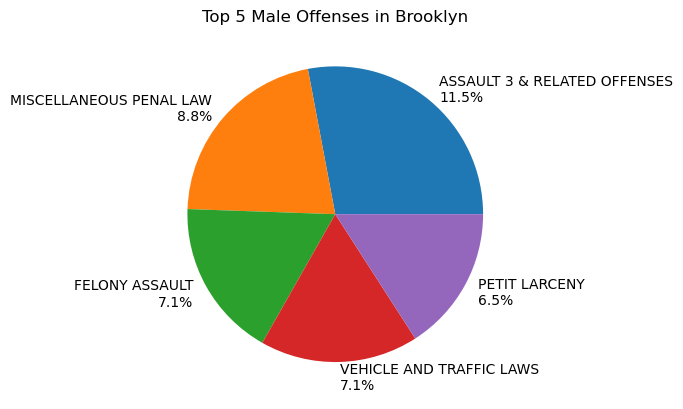

In [27]:
#visualizing top 5 offenses overall by males via pie chart
plt.pie(
    male_top_5['Count'],
    labels=[
        f"{offense}\n{pct:.1f}%"
        for offense, pct in zip(
            male_top_5['OFNS_DESC'],
            male_top_5['Percentage'])])

plt.title('Top 5 Male Offenses in Brooklyn')
plt.show()

In [32]:
#identifying the top 3 offenses out of all level of offense for females
female_offenses = brooklyn_df[brooklyn_df['PERP_SEX'] == 'F'].groupby(['OFNS_DESC', 'Level of Offense']).size().reset_index(name='Count')

# Calculate percentage out of ALL female arrests in Brooklyn
female_offenses['Percentage'] = (female_offenses['Count'] / female_offenses['Count'].sum()) * 100

# Get top 3 overall female offenses
female_top_5 = female_offenses.sort_values('Count', ascending=False).head(5)

print(female_top_5)


                       OFNS_DESC Level of Offense  Count  Percentage
3   ASSAULT 3 & RELATED OFFENSES      Misdemeanor    641   21.253316
15                FELONY ASSAULT           Felony    432   14.323607
27       MISCELLANEOUS PENAL LAW           Felony    278    9.217507
43                 PETIT LARCENY      Misdemeanor    258    8.554377
12               DANGEROUS DRUGS      Misdemeanor    154    5.106101


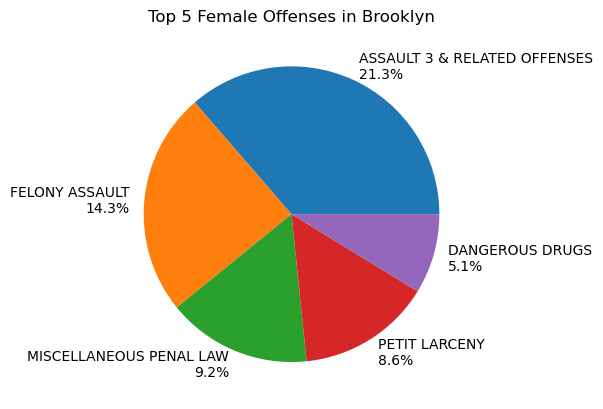

In [33]:
#visualizing top 5 via pie chart
plt.pie(
    female_top_5['Count'],
    labels=[
        f"{offense}\n{pct:.1f}%"
        for offense, pct in zip(
            female_top_5['OFNS_DESC'],
            female_top_5['Percentage'])])

plt.title('Top 5 Female Offenses in Brooklyn')
plt.show()

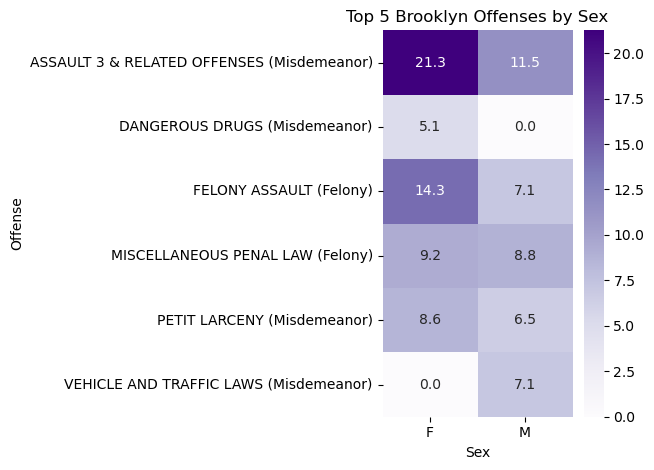

In [34]:
# Group by sex, level of offense, and offense description
brooklyn_offenses = brooklyn_df.groupby(['PERP_SEX', 'Level of Offense', 'OFNS_DESC']).size().reset_index(name='Count')

# Calculate percentage out of all arrests within each sex group
brooklyn_offenses['Percentage'] = (brooklyn_offenses['Count']/brooklyn_offenses.groupby('PERP_SEX')['Count'].transform('sum')) * 100

# Sort by sex and count
brooklyn_offenses = brooklyn_offenses.sort_values(['PERP_SEX', 'Count'], ascending=[True, False])

# Get top 5 offenses overall for each sex
top_offenses = brooklyn_offenses.groupby('PERP_SEX').head(5)

# Create label that includes offense and level of offense
top_offenses['Offense_Label'] = (top_offenses['OFNS_DESC'] +' (' +top_offenses['Level of Offense'] +')')

# Create heatmap table
heatmap_data = top_offenses.pivot_table(
    index='Offense_Label',
    columns='PERP_SEX',
    values='Percentage',
    fill_value=0)

# Create heatmap
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='Purples')

plt.title('Top 5 Brooklyn Offenses by Sex')
plt.xlabel('Sex')
plt.ylabel('Offense')
plt.tight_layout()
plt.show()

In [35]:
#This analysis began with overall New York City arrest patterns and then focused specifically on Brooklyn, 
#which accounted for approximately 33% of all arrests in the dataset. Within Brooklyn, most arrests involved 
#males (81.86%), with misdemeanors and felonies representing the majority of offenses for both males and females. 
#The most common offense across both groups was “Assault 3 & Related Offenses,” while several of the top five offenses 
#were shared between males and females. These findings may contain bias because arrest data can reflect policing practices, 
#enforcement priorities, and neighborhood surveillance rather than actual crime rates alone.